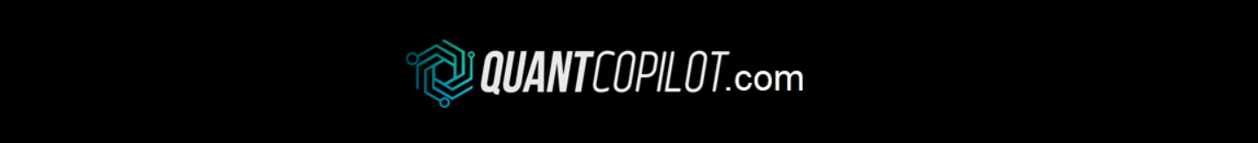

<font color='red'>**NOTA IMPORTANTE:**</font> Ya que el web data reader ha sido descontinuado, en este notebook se han reemplazado todas las instancias del web data reader, por el paquete **YFinance**. Todo lo demás es exactamente como en los videos del curso.

# Dukascopy

# Cargando archivos .csv desde el Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import pandas as pd

In [ ]:
data = pd.read_csv("-------ruta a archivo .csv-------") 

In [ ]:
data.head()

,Local time,Open,High,Low,Close,Volume
0,31.12.2019 19:00:00.000 GMT-0500,1.12172,1.12228,1.12124,1.12191,2467.0437
1,01.01.2020 19:00:00.000 GMT-0500,1.12192,1.12247,1.11638,1.11711,282438.7500
2,02.01.2020 19:00:00.000 GMT-0500,1.11711,1.11800,1.11251,1.11626,222676.6875
3,04.01.2020 19:00:00.000 GMT-0500,1.11687,1.11703,1.11596,1.11608,4151.2300
4,05.01.2020 19:00:00.000 GMT-0500,1.11605,1.12058,1.11574,1.11956,136739.5000


In [ ]:
data.tail()

,Local time,Open,High,Low,Close,Volume
329,18.01.2021 19:00:00.000 GMT-0500,1.20779,1.21452,1.20776,1.21396,131027.0850
330,19.01.2021 19:00:00.000 GMT-0500,1.21396,1.21585,1.20768,1.21150,130083.4127
331,20.01.2021 19:00:00.000 GMT-0500,1.21150,1.21733,1.21096,1.21659,139868.8850
332,21.01.2021 19:00:00.000 GMT-0500,1.21658,1.21898,1.21518,1.21745,125671.3550
333,23.01.2021 19:00:00.000 GMT-0500,1.21730,1.21738,1.21647,1.21672,3779.4951


In [5]:
data.info()

NameError: name 'data' is not defined

In [ ]:
data.iloc[3,4]

1.11608

# YFinance

In [ ]:
pip install yfinance --upgrade --no-cache-dir

In [1]:
import pandas as pd
import yfinance as yf

import matplotlib.pyplot as plt

import matplotlib.style
plt.style.use('ggplot')

### Declarando Variables

In [3]:
asset = 'TSLA'
start_date = '2015-01-01'
end_date = '2021-01-01'

### Importando 

In [4]:
df = yf.download(asset, interval='1d', start=start_date, end=end_date)

/var/folders/rj/zpjy_9893s71m_6fssmmczl00000gn/T/ipykernel_57102/3010164123.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(asset, interval='1d', start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


In [ ]:
df

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2015-01-02,222.630005,223.250000,213.259995,219.309998,219.309998,4764443
2015-01-05,214.500000,216.500000,207.162598,210.089996,210.089996,5368477
2015-01-06,210.059998,214.199997,204.210007,211.279999,211.279999,6261936
2015-01-07,213.399994,214.779999,209.779999,210.949997,210.949997,2968390
2015-01-08,212.809998,213.799896,210.009995,210.615005,210.615005,3442509
...,...,...,...,...,...,...
2020-12-24,642.989990,666.090027,641.000000,661.770020,661.770020,22865568
2020-12-28,674.510010,681.400024,660.799988,663.690002,663.690002,32278561
2020-12-29,661.000000,669.900024,655.000000,665.989990,665.989990,22910811


# Obteniendo multiples activos *(for loops)*

In [ ]:
# Fuente remota - Yahoo
assets = ['EURUSD=X', 'AUDEUR=X', 'USDGBP=X']
data = yf.download(assets, interval='1d', start='2015-01-01', end='2021-01-01')

[*********************100%***********************]  3 of 3 completed


In [ ]:
data.head(3)

Adj Close                     ...   Volume                  
            AUDEUR=X  EURUSD=X USDGBP=X  ... AUDEUR=X EURUSD=X USDGBP=X
Date                                     ...                           
2015-01-01   0.67479  1.209863  0.64181  ...        0      0.0      0.0
2015-01-02   0.67620  1.208941  0.64186  ...        0      0.0      0.0
2015-01-05   0.67530  1.194643  0.65424  ...        0      0.0      0.0

[3 rows x 18 columns]

In [ ]:
data.loc['2020-06-03']

Adj Close  AUDEUR=X    0.618050
           EURUSD=X    1.118944
           USDGBP=X    0.794820
Close      AUDEUR=X    0.618050
           EURUSD=X    1.118944
           USDGBP=X    0.794820
High       AUDEUR=X    0.623600
           EURUSD=X    1.124999
           USDGBP=X    0.796500
Low        AUDEUR=X    0.613000
           EURUSD=X    1.118105
           USDGBP=X    0.792830
Open       AUDEUR=X    0.618180
           EURUSD=X    1.118568
           USDGBP=X    0.794980
Volume     AUDEUR=X    0.000000
           EURUSD=X    0.000000
           USDGBP=X    0.000000
Name: 2020-06-03 00:00:00, dtype: float64

Como vemos, hemos descargado todas las columnas para todos los activos, pero solo queremos las columnas 'High' de cada activo. Hagamos precisamente eso:

In [ ]:
# Fuente remota - Yahoo
assets = ['EURUSD=X', 'AUDEUR=X', 'USDGBP=X']

# Iteremos para obtener solo la columna 'Adj Close' de cada activo
data = pd.DataFrame()
for i in assets:
  data[i] = yf.download(i, interval='1d', start='2015-01-01', end='2021-01-01')['High']

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [ ]:
data.head(3)

,EURUSD=X,AUDEUR=X,USDGBP=X
Date,,,
2015-01-01,1.209863,0.67613,0.64181
2015-01-02,1.208956,0.67710,0.64988
2015-01-05,1.197590,0.67850,0.65763


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1564 entries, 2015-01-01 to 2021-01-01
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   EURUSD=X  1564 non-null   float64
 1   AUDEUR=X  1564 non-null   float64
 2   USDGBP=X  1564 non-null   float64
dtypes: float64(3)
memory usage: 48.9 KB


# Guandando data en archivo

## Guardando en Drive

In [ ]:
# Mounting Drive
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
df.to_csv(r'----ruta del directorio incluido el nombre del archivo .csv a ser guardado-----') #

# Visualizando los datos

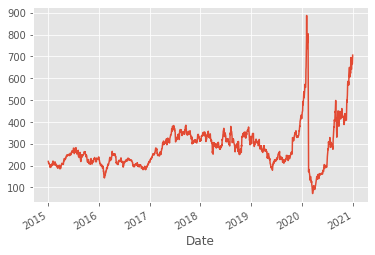

In [ ]:
df['Adj Close'].plot(); 

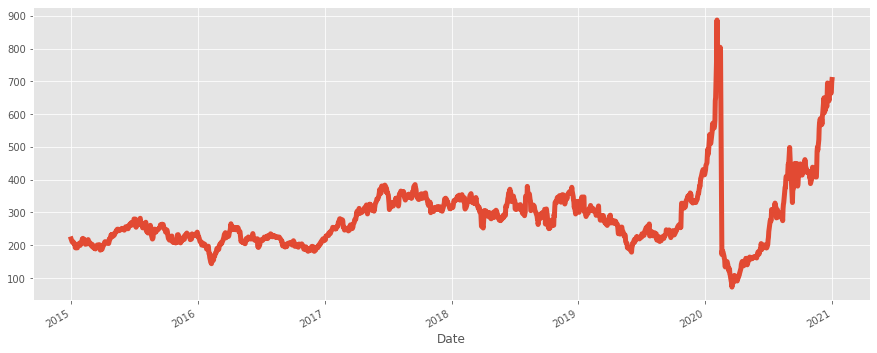

In [ ]:
df['Adj Close'].plot(figsize=(15, 6), lw=5);

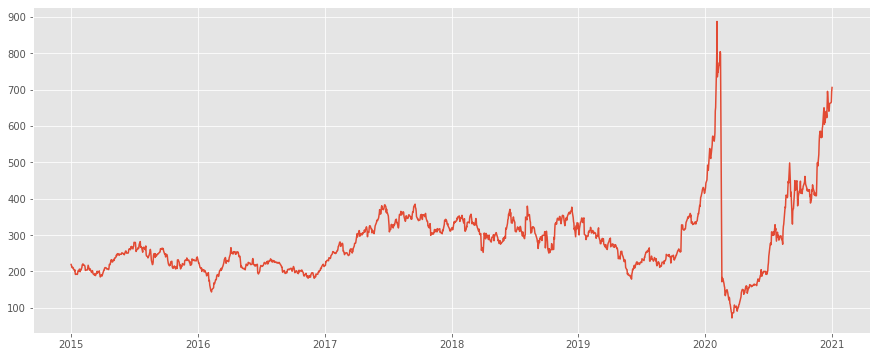

In [ ]:
plt.figure(figsize=(15,6))
plt.plot(df['Adj Close'])
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1511 entries, 2015-01-02 to 2020-12-31
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       1511 non-null   float64
 1   High       1511 non-null   float64
 2   Low        1511 non-null   float64
 3   Close      1511 non-null   float64
 4   Adj Close  1511 non-null   float64
 5   Volume     1511 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 82.6 KB


In [ ]:
# Convertiendo valores enteros (integers) a decimales (float)
df['Volume'] = df['Volume'].astype(float)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1511 entries, 2015-01-02 to 2020-12-31
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       1511 non-null   float64
 1   High       1511 non-null   float64
 2   Low        1511 non-null   float64
 3   Close      1511 non-null   float64
 4   Adj Close  1511 non-null   float64
 5   Volume     1511 non-null   float64
dtypes: float64(6)
memory usage: 82.6 KB


------
*Pandas datareader es util, pero ultimamente se han experiemntado limitaciones ya que la API de yahoo ha cambiado mucho a lo largo de los ultimos anos, es por eso que se han creado mejores optiones para extraer datos financieros de Yahoo Finance*

# Libreria Yfinance

Yfinance GitHub: https://github.com/ranaroussi/yfinance

In [ ]:
pip install yfinance --upgrade --no-cache-dir

In [ ]:
import yfinance as yf

In [6]:
# Opcion 1: Usar 'start' y 'end'
df2 = yf.download("TSLA", interval='1d', start=start_date, end=end_date)

/var/folders/rj/zpjy_9893s71m_6fssmmczl00000gn/T/ipykernel_57102/2902326315.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df2 = yf.download("TSLA", interval='1d', start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


In [ ]:
df2

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2015-01-02,222.630005,223.250000,213.259995,219.309998,219.309998,4764443
2015-01-05,214.500000,216.500000,207.162598,210.089996,210.089996,5368477
2015-01-06,210.059998,214.199997,204.210007,211.279999,211.279999,6261936
2015-01-07,213.399994,214.779999,209.779999,210.949997,210.949997,2968390
2015-01-08,212.809998,213.799896,210.009995,210.615005,210.615005,3442509
...,...,...,...,...,...,...
2020-12-24,642.989990,666.090027,641.000000,661.770020,661.770020,22865568
2020-12-28,674.510010,681.400024,660.799988,663.690002,663.690002,32278561
2020-12-29,661.000000,669.900024,655.000000,665.989990,665.989990,22910811


In [ ]:
# Opcion 2: Usar PERIOD en lugar de 'start' y 'end'
df2 = yf.download("GOOG", period='10y', interval='1d')

[*********************100%***********************]  1 of 1 completed


In [ ]:
df2

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-03-27,566.445129,566.445129,551.406372,556.931213,556.931213,13087
2014-03-28,559.713562,564.879395,557.140625,558.457031,558.457031,41115
2014-03-31,565.338135,565.447815,555.405396,555.445312,555.445312,10801
2014-04-01,557.180542,566.893860,557.180542,565.607422,565.607422,7953
2014-04-02,579.170166,603.174316,560.651001,565.447815,565.447815,147099
...,...,...,...,...,...,...
2021-12-06,2871.479980,2887.030029,2812.939941,2875.929932,2875.929932,1109885
2021-12-07,2919.000000,2966.000000,2914.050049,2960.729980,2960.729980,1162914
2021-12-08,2966.629883,2983.129883,2944.000000,2974.409912,2974.409912,923792


## Yfinance para varios Tickers

In [ ]:
assets = ["EURUSD=X", "EURGBP=X", "AUDUSD=X"]

In [ ]:
# Creamos un DataFrame vacio que va a contener con los precios de cierre de
# todos lostickers descritos arriba
precio_de_cierre = pd.DataFrame()

In [ ]:
# Por cada activo o ticker seleccionado, va a descargar y almacenar el precio de
# cierre (Adj Close) de cada ticker
for ticker in assets:
  precio_de_cierre[ticker] = yf.download(ticker, period='2y', interval='1d')["Open"]

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [ ]:
precio_de_cierre

,EURUSD=X,EURGBP=X,AUDUSD=X
Date,,,
2019-12-10,1.106452,0.84155,0.682700
2019-12-11,1.109385,0.84473,0.681290
2019-12-12,1.113325,0.84333,0.687059
2019-12-13,1.118343,0.82979,0.692521
2019-12-16,1.112520,0.83297,0.687520
...,...,...,...
2021-12-06,1.130263,0.85407,0.701661
2021-12-07,1.128452,0.85071,0.705119
2021-12-08,1.127307,0.85095,0.712240


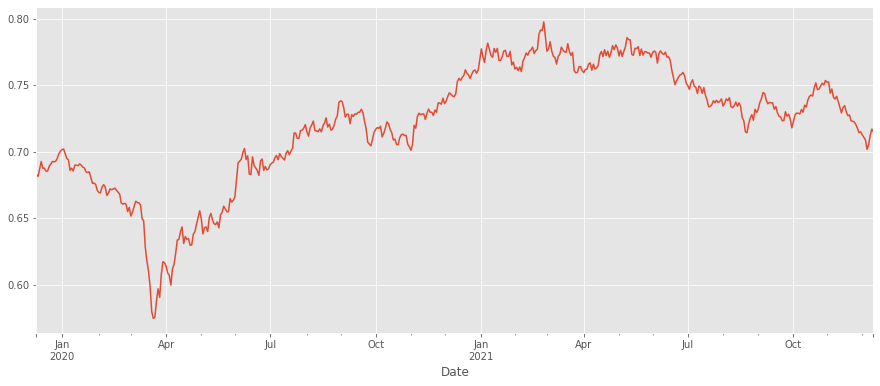

In [ ]:
precio_de_cierre["AUDUSD=X"].plot(figsize=(15, 6));

Ahora si queremos almacenar todos las columnas de cada ticker (Open, High, Close, Adj Close, Volume, etc), tenemos que crear un DICCIONARIO. Sabemos ya que los diccionarios almacenan valores en "pares". En este caso la Clave o key sera el Ticker, y su valor sera el DataFrame (columnas de cada ticker).

In [ ]:
ohlcv_data = {} # Diccionario vacio

In [ ]:
for ticker in assets:
  ohlcv_data[ticker] = yf.download(ticker, period='2y', interval='1d')

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [ ]:
ohlcv_data

{'AUDUSD=X':                 Open      High       Low     Close  Adj Close  Volume
 Date                                                                 
 2019-12-10  0.682700  0.683900  0.680092  0.682800   0.682800       0
 2019-12-11  0.681290  0.686900  0.680520  0.681140   0.681140       0
 2019-12-12  0.687059  0.690880  0.687059  0.687049   0.687049       0
 2019-12-13  0.692521  0.693000  0.686530  0.692713   0.692713       0
 2019-12-16  0.687520  0.690000  0.686950  0.687479   0.687479       0
 ...              ...       ...       ...       ...        ...     ...
 2021-12-06  0.701661  0.705348  0.700722  0.701790   0.701790       0
 2021-12-07  0.705119  0.712500  0.704040  0.704920   0.704920       0
 2021-12-08  0.712240  0.717010  0.711790  0.712260   0.712260       0
 2021-12-09  0.716897  0.718907  0.713600  0.717000   0.717000       0
 2021-12-10  0.714694  0.718272  0.713419  0.714612   0.714612       0
 
 [524 rows x 6 columns],
 'EURGBP=X':                Open     H

In [ ]:
ohlcv_data["EURUSD=X"]

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2019-12-10,1.106452,1.109755,1.106354,1.106499,1.106499,0
2019-12-11,1.109385,1.109878,1.107175,1.109275,1.109275,0
2019-12-12,1.113325,1.115337,1.111185,1.113586,1.113586,0
2019-12-13,1.118343,1.118693,1.111889,1.118606,1.118606,0
2019-12-16,1.112520,1.115785,1.112347,1.112446,1.112446,0
...,...,...,...,...,...,...
2021-12-06,1.130263,1.131000,1.126900,1.130480,1.130480,0
2021-12-07,1.128452,1.129943,1.123129,1.128668,1.128668,0
2021-12-08,1.127307,1.133903,1.126964,1.127650,1.127650,0


In [ ]:
ohlcv_data["EURUSD=X"]["Open"]

Date
2019-12-10    1.106452
2019-12-11    1.109385
2019-12-12    1.113325
2019-12-13    1.118343
2019-12-16    1.112520
                ...   
2021-12-06    1.130263
2021-12-07    1.128452
2021-12-08    1.127307
2021-12-09    1.134404
2021-12-10    1.129408
Name: Open, Length: 524, dtype: float64